# SMS Spam Detection Using Natural Language Processing

**Course:** DS483 - Natural Language Processing

This project develops an NLP-based system to classify SMS messages as ham or spam. Different NLP techniques and classification models will be implemented and compared throughout the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
df = pd.read_csv(
    '/content/SMSSpamCollection',
    sep='\t',
    names=['label', 'message']
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df['label'].value_counts())

Dataset shape: (5572, 2)

Missing values:
label      0
message    0
dtype: int64

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


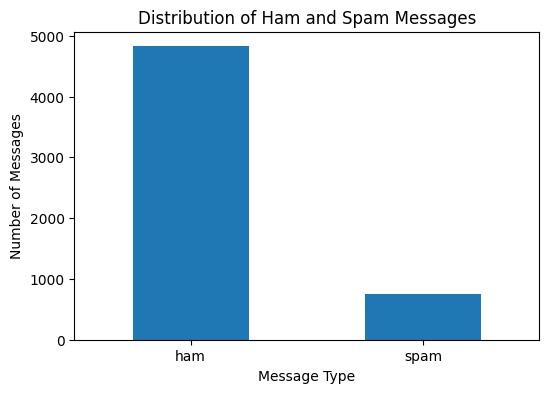

In [4]:
class_counts = df['label'].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar')

plt.title('Distribution of Ham and Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.xticks(rotation=0)
plt.show()

In [5]:
df['message_length'] = df['message'].apply(len)

length_stats = df.groupby('label')['message_length'].agg(['mean', 'median', 'min', 'max'])
length_stats

,mean,median,min,max
label,,,,
ham,71.482487,52.0,2,910
spam,138.670683,149.0,13,223


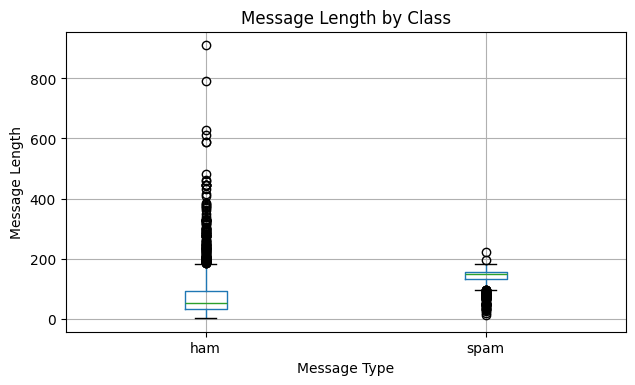

In [6]:
df.boxplot(column='message_length', by='label', figsize=(7, 4))

plt.title('Message Length by Class')
plt.suptitle('')
plt.xlabel('Message Type')
plt.ylabel('Message Length')
plt.show()

## Text Preprocessing

The SMS messages are preprocessed to reduce unnecessary text variations and prepare the data for NLP analysis.

In [7]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

print("Number of English stopwords:", len(stop_words))

Number of English stopwords: 198


In [8]:
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove non-alphabetic characters and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Apply stemming
    tokens = [stemmer.stem(word) for word in tokens]

    # Join tokens back into a single string
    return ' '.join(tokens)

In [9]:
spam_example = df[df['label'] == 'spam']['message'].iloc[0]

print("Before preprocessing:")
print(spam_example)

print("\nAfter preprocessing:")
print(preprocess_text(spam_example))

Before preprocessing:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

After preprocessing:
free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over


In [10]:
df['processed_message'] = df['message'].apply(preprocess_text)

df[['label', 'message', 'processed_message']].head()

,label,message,processed_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


In [11]:
examples = pd.concat([
    df[df['label'] == 'ham'].head(2),
    df[df['label'] == 'spam'].head(2)
])

examples[['label', 'message', 'processed_message']]

,label,message,processed_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back id like fun st...


### Preprocessing Justification

The preprocessing steps were selected to make the SMS messages more consistent and reduce unnecessary noise. All text was converted to lowercase to avoid treating the same word differently because of capitalization. URLs, punctuation, numbers, and special characters were removed because they may add unnecessary variations to the text. Tokenization was used to split each message into individual words, while common English stopwords were removed to focus on more meaningful terms. Finally, stemming was applied to reduce related words to a simpler common form. The original messages were kept in a separate column so that the effect of preprocessing could be compared clearly.

In [12]:
empty_messages = (df['processed_message'].str.strip() == '').sum()

print("Empty messages after preprocessing:", empty_messages)

Empty messages after preprocessing: 6


In [13]:
empty_rows = df[df['processed_message'].str.strip() == '']

empty_rows[['label', 'message', 'processed_message']]

,label,message,processed_message
960,ham,Where @,
1612,ham,645,
2807,ham,Can a not?,
3376,ham,:),
4575,ham,:( but your not here....,
4824,ham,:-) :-),


In [14]:
empty_mask = df['processed_message'].str.strip() == ''

df.loc[empty_mask, 'processed_message'] = (
    df.loc[empty_mask, 'message']
    .str.lower()
    .str.strip()
)

print("Empty messages after handling:",
      (df['processed_message'].str.strip() == '').sum())

Empty messages after handling: 0
